**Q1. (a) Use total least squares to fit the lines to only using the data corresponding to the first line. Report the resulting parameters.**

In [ ]:
import numpy as np


D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)

# Extract ONLY first line (x1, y1)
x = D[:, 0]
y = D[:, 3]

def total_least_squares(x, y):
    # Step 1: Compute centroid
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    # Step 2: Center the data
    X = np.vstack((x - x_mean, y - y_mean)).T

    # Step 3: Compute covariance matrix (U^T U)
    S = X.T @ X

    # Step 4: Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eig(S)

    # Step 5: Smallest eigenvalue -> normal vector
    idx = np.argmin(eigenvalues)
    a, b = eigenvectors[:, idx]

    # Normalize (optional but good practice)
    norm = np.sqrt(a**2 + b**2)
    a, b = a / norm, b / norm

    # Step 6: Compute d
    d = a * x_mean + b * y_mean

    return a, b, d

a, b, d = total_least_squares(x, y)

print("Line Parameters")
print(f"a = {a}, b = {b}, d = {d}")
print(f"Line equation: {a}x + {b}y = {d}")

Line Parameters
a = -0.7735616496467873, b = 0.6337210539312553, d = -3.794192210845812
Line equation: -0.7735616496467873x + 0.6337210539312553y = -3.794192210845812


**Q1. (b) use all the points as indicate in the code snippet below and fit three lines**

In [ ]:
import numpy as np


D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)


X_cols = D[:, :3]
Y_cols = D[:, 3:]

X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

points = np.vstack((X_all, Y_all)).T




def fit_line_from_points(p1, p2):
    # Fit line ax + by = d from 2 points

    x1, y1 = p1
    x2, y2 = p2

    # Line normal vector (a, b)
    a = y2 - y1
    b = -(x2 - x1)

    # Normalize
    norm = np.sqrt(a**2 + b**2)
    if norm == 0:
        return None

    a, b = a / norm, b / norm
    d = a * x1 + b * y1

    return a, b, d


def compute_distance(a, b, d, points):
    # Perpendicular distance from points to line

    return np.abs(a * points[:, 0] + b * points[:, 1] - d)


def ransac_line(points, num_iterations=1000, threshold=0.2, min_inliers=20):
    best_model = None
    best_inliers = []

    n_points = len(points)

    for _ in range(num_iterations):
        # Randomly sample 2 points
        idx = np.random.choice(n_points, 2, replace=False)
        p1, p2 = points[idx]

        model = fit_line_from_points(p1, p2)
        if model is None:
            continue

        a, b, d = model

        # Compute distances
        distances = compute_distance(a, b, d, points)

        # Find inliers
        inliers = points[distances < threshold]

        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (a, b, d)

    # Refit using all inliers (TLS for better accuracy)
    if best_model is not None and len(best_inliers) >= min_inliers:
        x = best_inliers[:, 0]
        y = best_inliers[:, 1]
        a, b, d = total_least_squares(x, y)
        return (a, b, d), best_inliers

    return None, None


# ---------- Find 3 lines ----------

remaining_points = points.copy()
lines = []

for i in range(3):
    model, inliers = ransac_line(remaining_points)

    if model is None:
        break

    lines.append(model)

    # Remove inliers for next iteration
    mask = np.ones(len(remaining_points), dtype=bool)
    for pt in inliers:
        mask &= ~np.all(remaining_points == pt, axis=1)

    remaining_points = remaining_points[mask]


# ---------- Print Results ----------

print("\nRANSAC detected lines")

for i, (a, b, d) in enumerate(lines):
    print(f"\nLine {i+1}:")
    print(f"a = {a}, b = {b}, d = {d}")
    print(f"Equation: {a}x + {b}y = {d}")


RANSAC detected lines

Line 1:
a = -0.7184167043119765, b = 0.6956129951097221, d = 0.638702282340126
Equation: -0.7184167043119765x + 0.6956129951097221y = 0.638702282340126

Line 2:
a = 0.46489695627333794, b = 0.8853647948996991, d = 1.933771598674861
Equation: 0.46489695627333794x + 0.8853647948996991y = 1.933771598674861

Line 3:
a = -0.770255142602224, b = 0.6377358507209921, d = -3.809491294646967
Equation: -0.770255142602224x + 0.6377358507209921y = -3.809491294646967


**Q2. what are the sizes of the earrings?**

Width (pixels): 381
Height (pixels): 388


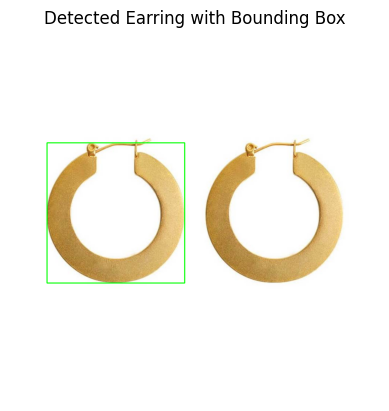

Real Width (mm): 75.438
Real Height (mm): 76.824


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img = cv.imread('earrings.jpg')
assert img is not None, "Image not found"

# Convert to grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Blur to reduce noise
blur = cv.GaussianBlur(gray, (5, 5), 0)

# Edge detection
edges = cv.Canny(blur, 50, 200)

# Find contours
contours, _ = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Select the largest contour (one earring)
cnt = max(contours, key=cv.contourArea)

# Bounding box (width & height in pixels)
x, y, w, h = cv.boundingRect(cnt)

print("Width (pixels):", w)
print("Height (pixels):", h)

# Draw bounding box for visualization
output = img.copy()
cv.rectangle(output, (x, y), (x+w, y+h), (0, 255, 0), 2)

# Display result
plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
plt.title("Detected Earring with Bounding Box")
plt.axis('off')
plt.show()

# Convert to real-world size
pixel_size_mm = 2.2e-3   # 2.2 micrometers
f = 8                    # focal length (mm)
D = 720                  # distance (mm)

m = f / D

width_mm = (w * pixel_size_mm) / m
height_mm = (h * pixel_size_mm) / m

print("Real Width (mm):", width_mm)
print("Real Height (mm):", height_mm)

**Q3.(a) Manually click about 6 corresponding points in each circuit board, compute the homography, and warp one image to the perspective of the other. Display the warped image.**

In [10]:
# (a) HOMOGRAPHY FROM MANUAL POINTS + WARP

import cv2 as cv
import numpy as np

# PARAMETERS
N = 6
n = 0
p1 = np.zeros((N, 2), dtype=np.float32)
p2 = np.zeros((N, 2), dtype=np.float32)


# RESIZE FUNCTION (for display only)
def resize_for_display(img, max_width=900, max_height=700):
    h, w = img.shape[:2]
    scale = min(max_width / w, max_height / h)
    if scale < 1:
        img = cv.resize(img, (int(w*scale), int(h*scale)))
    return img


# MOUSE FUNCTION
def draw_circle(event, x, y, flags, param):
    global n
    pts, img = param
    if event == cv.EVENT_LBUTTONDOWN and n < N:
        cv.circle(img, (x, y), 5, (0, 0, 255), -1)
        pts[n] = [x, y]
        n += 1


# LOAD FULL-RES IMAGES
im1 = cv.imread('c1.jpg')
im2 = cv.imread('c2.jpg')

im1copy = im1.copy()
im2copy = im2.copy()


# CLICK POINTS (DISPLAY RESIZED, STORE ORIGINAL COORDS)
def collect_points(image, points, window_name):
    global n
    n = 0

    display = resize_for_display(image.copy())
    scale_x = image.shape[1] / display.shape[1]
    scale_y = image.shape[0] / display.shape[0]

    def callback(event, x, y, flags, param):
        global n
        if event == cv.EVENT_LBUTTONDOWN and n < N:
            # scale back to original image coordinates
            orig_x = int(x * scale_x)
            orig_y = int(y * scale_y)

            cv.circle(display, (x, y), 5, (0, 0, 255), -1)
            points[n] = [orig_x, orig_y]
            n += 1

    cv.namedWindow(window_name)
    cv.setMouseCallback(window_name, callback)

    while True:
        cv.imshow(window_name, display)
        if n == N:
            break
        if cv.waitKey(20) & 0xFF == 27:
            break

    cv.destroyWindow(window_name)

# Collect points
collect_points(im1, p1, "Image 1")
collect_points(im2, p2, "Image 2")

print("Points Image1:\n", p1)
print("Points Image2:\n", p2)


# HOMOGRAPHY + WARP
H, _ = cv.findHomography(p1, p2, cv.RANSAC)

h, w = im2.shape[:2]
warped = cv.warpPerspective(im1, H, (w, h))


# DISPLAY (RESIZED)
cv.imshow("Warped", resize_for_display(warped))
cv.imshow("Target Image", resize_for_display(im2))

overlay = cv.addWeighted(warped, 0.5, im2, 0.5, 0)
cv.imshow("Overlay", resize_for_display(overlay))

cv.waitKey(0)
cv.destroyAllWindows()

Points Image1:
 [[ 901.  966.]
 [1619. 1122.]
 [ 819. 1196.]
 [1404. 1707.]
 [ 534. 2038.]
 [1139. 2241.]]
Points Image2:
 [[1019.  786.]
 [1678. 1115.]
 [ 876.  990.]
 [1313. 1630.]
 [ 382. 1712.]
 [ 919. 2084.]]


In [11]:

# (b) DIFFERENCE IMAGE (FIXED DISPLAY)


def resize_for_display(img, max_width=900, max_height=700):
    h, w = img.shape[:2]
    scale = min(max_width / w, max_height / h)
    if scale < 1:
        img = cv.resize(img, (int(w*scale), int(h*scale)))
    return img

# Convert to grayscale
gray_warp = cv.cvtColor(warped, cv.COLOR_BGR2GRAY)
gray_im2 = cv.cvtColor(im2, cv.COLOR_BGR2GRAY)

# Compute difference
diff = cv.absdiff(gray_warp, gray_im2)

# Threshold for visibility
_, diff_thresh = cv.threshold(diff, 30, 255, cv.THRESH_BINARY)

# Display (resized)
cv.imshow("Difference", resize_for_display(diff))
cv.imshow("Thresholded Difference", resize_for_display(diff_thresh))

cv.waitKey(0)
cv.destroyAllWindows()

In [12]:

# (c) ORB FEATURE MATCHING (FIXED DISPLAY)


def resize_for_display(img, max_width=1200, max_height=700):
    h, w = img.shape[:2]
    scale = min(max_width / w, max_height / h)
    if scale < 1:
        img = cv.resize(img, (int(w*scale), int(h*scale)))
    return img

# Convert to grayscale
gray1 = cv.cvtColor(im1, cv.COLOR_BGR2GRAY)
gray2 = cv.cvtColor(im2, cv.COLOR_BGR2GRAY)

# ORB detector
orb = cv.ORB_create(2000)

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

# Matcher
bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

# Draw matches
match_img = cv.drawMatches(im1, kp1, im2, kp2,
                          matches[:50], None,
                          flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display resized
cv.imshow("ORB Matches", resize_for_display(match_img))

cv.waitKey(0)
cv.destroyAllWindows()

In [13]:

# (d) HOMOGRAPHY FROM ORB MATCHES


def resize_for_display(img, max_width=900, max_height=700):
    h, w = img.shape[:2]
    scale = min(max_width / w, max_height / h)
    if scale < 1:
        img = cv.resize(img, (int(w*scale), int(h*scale)))
    return img

# Extract matched points
pts1 = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

# Homography with RANSAC
H_orb, _ = cv.findHomography(pts1, pts2, cv.RANSAC, 5.0)

# Warp
h, w = im2.shape[:2]
warped_orb = cv.warpPerspective(im1, H_orb, (w, h))

# Difference
gray_warp_orb = cv.cvtColor(warped_orb, cv.COLOR_BGR2GRAY)
gray_im2 = cv.cvtColor(im2, cv.COLOR_BGR2GRAY)

diff_orb = cv.absdiff(gray_warp_orb, gray_im2)
_, diff_orb_thresh = cv.threshold(diff_orb, 30, 255, cv.THRESH_BINARY)

# Display resized
cv.imshow("Warped ORB", resize_for_display(warped_orb))
cv.imshow("Difference ORB", resize_for_display(diff_orb))
cv.imshow("Thresholded Difference ORB", resize_for_display(diff_orb_thresh))

# Overlay 
overlay = cv.addWeighted(warped_orb, 0.5, im2, 0.5, 0)
cv.imshow("Overlay ORB", resize_for_display(overlay))

cv.waitKey(0)
cv.destroyAllWindows()